In [1]:
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_config_filepath, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import copy

# Reservoir hyperparameters

In [2]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config2.json")

# Generate new models or load pretrained models

In [5]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible
sq_th not possible


In [3]:
QReservoir_models = []

for i in range(n_models):
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    Qres = QReservoir.init_from_file(systempath)
    QReservoir_models.append(Qres)

# Generate test inputs and their entanglement values

In [4]:
test_ST_data = [list(gen_input_states("ST", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_PASV_data = [list(gen_input_states("PASV_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_PSSV_data = [list(gen_input_states("PSSV_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]
test_QUBIT_data = [list(gen_input_states("QUBIT_split", n_test_inputs, fock_truncation, True, sim_rounding)) for _ in range(n_models)]

test_ST, test_ST_ent, test_PASV, test_PASV_ent, test_PSSV, test_PSSV_ent, test_QUBIT, test_QUBIT_ent = [], [], [], [], [], [], [], []

for i in range(n_models):
    test_ST.append(test_ST_data[i][0])
    test_ST_ent.append(test_ST_data[i][1])
    test_PASV.append(test_PASV_data[i][0])
    test_PASV_ent.append(test_PASV_data[i][1])
    test_PSSV.append(test_PSSV_data[i][0])
    test_PSSV_ent.append(test_PSSV_data[i][1])
    test_QUBIT.append(test_QUBIT_data[i][0])
    test_QUBIT_ent.append(test_QUBIT_data[i][1])


# Model training for new models

In [ ]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999859999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000113554+0j)
tr_res: (1+0j)
tr_new: (1.000000050224+0j)
tr_res: (1+0j)
tr_new: (1.0000000073909998+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999971996+0j)
tr_res: (1+0j)
tr_new: (1.000000005525+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999701420001+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999919843+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998639629999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999893769+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999904945+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997577830001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997633800001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.99999970191+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997019200002+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996683779999+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999655349+0j)
tr_res: (0.9999

In [ ]:
QReservoir_models[7] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_inputs[7] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)

QReservoir_models[7].init_reservoir("vacuum")
QReservoir_models[7].rk4_timesteps(4)

In [ ]:
QReservoir_models[7].train_reservoir(train_inputs[7])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 7)
QReservoir_models[7].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.999999999988+0j)
0
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998597469999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998102050001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996454169999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995779640001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995217850001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995794130001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995654739999+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994804679999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999564541+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995387629999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999578955+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999669995+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996601269999+0j)
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999611612+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994765600001+0j)
tr_res: (0.99

# Test models / Evaluate entanglement classification

In [5]:
resultpath = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity))
resultpath_cm = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity, True))

In [ ]:
res = QReservoir_models[0].analyze_performance(QReservoir_models[0].test_Y_true, QReservoir_models[0].test_Y_pred)
write_to_row(str(res), resultpath)

# Squeezed thermal states

In [6]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_ST[i], test_ST_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995436460002+0j)
0
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999551229+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996277000001+0j)
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999628531+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996413740001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996373140001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.99999970387+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999997092650001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999688186+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996861909999+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999701997+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999997489049999+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996444370001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996476740001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997053199998+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999714315+0j)

# Photon added squeezed vacuum states

In [ ]:
for i in range(2,n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_PASV[i], test_PASV_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

tr_res: (1.0000019073486328+0j)
tr_new: (1.000001924397+0j)
0
tr_res: (1.0000020265579224+0j)
tr_new: (1.000001940667+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001878033+0j)
tr_res: (1.0000017881393433+0j)
tr_new: (1.00000183077+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001894805+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001916886+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001878588+0j)
tr_res: (1.0000017881393433+0j)
tr_new: (1.000001841367+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001870671+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001909616+0j)
tr_res: (1.0000019073486328+0j)
tr_new: (1.000001945852+0j)
tr_res: (1.0000020265579224+0j)
tr_new: (1.000001959991+0j)
tr_res: (1.0000020265579224+0j)
tr_new: (1.000002005102+0j)
tr_res: (1.0000020265579224+0j)
tr_new: (1.0000020060350001+0j)
tr_res: (1.0000020265579224+0j)
tr_new: (1.00000203115+0j)
tr_res: (1.0000020265579224+0j)
tr_new: (1.000002001786+0j)
tr_res: (1.0000020265579224+0j)
tr_n

KeyboardInterrupt: 

# Photon substracted squeezed vacuum states

In [ ]:
for i in range(2, n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_PSSV[i], test_PSSV_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

tr_res: (1.0000026226043701+0j)
tr_new: (1.000002663664+0j)
0
tr_res: (1.0000026226043701+0j)
tr_new: (1.0000026968409998+0j)
tr_res: (1.0000027418136597+0j)
tr_new: (1.000002720244+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.000002643116+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.0000026897379999+0j)
tr_res: (1.0000027418136597+0j)
tr_new: (1.0000027032460002+0j)
tr_res: (1.0000027418136597+0j)
tr_new: (1.000002669604+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.000002601264+0j)
tr_res: (1.0000025033950806+0j)
tr_new: (1.000002582114+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.000002556681+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.0000025753680002+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.0000025696000001+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.000002584038+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.000002584855+0j)
tr_res: (1.0000025033950806+0j)
tr_new: (1.000002568553+0j)
tr_res: (1.0000026226043701+0j)
tr_new: (1.0000025917220001+0j)
tr_res: (1.000

# Qubit states

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result, cm = QReservoir_models[i].test_reservoir(test_QUBIT[i], test_QUBIT_ent[i])
    write_to_row(str(result), resultpath)
    write_to_row(','.join(map(str, cm)), resultpath_cm)

finish_row(resultpath)
finish_row(resultpath_cm)

tr_res: (1.0000009536743164+0j)
tr_new: (1.0000009536743164+0j)
0
tr_res: (1.000001072883606+0j)
tr_new: (1.000001072883606+0j)
tr_res: (1.0000009536743164+0j)
tr_new: (1.0000009536743164+0j)
tr_res: (1.000001072883606+0j)
tr_new: (1.000001072883606-5.848000306230006e-09j)
tr_res: (1.0000009536743164-5.846000128428841e-09j)
tr_new: (1.0000011920928955-1.0799000804695424e-08j)
tr_res: (1.000001072883606-1.0804001249198336e-08j)
tr_new: (1.000001072883606-1.080100009431817e-08j)
tr_res: (1.000001072883606-1.0806000538821081e-08j)
tr_new: (1.000001072883606-1.0805000449920499e-08j)
tr_res: (1.000001072883606-1.0818999918171812e-08j)
tr_new: (1.000001072883606-1.0816999740370647e-08j)
tr_res: (1.000001072883606-1.0822999385595722e-08j)
tr_new: (1.000001072883606-1.0820000007072395e-08j)
tr_res: (1.0000009536743164-1.08310009849788e-08j)
tr_new: (1.0000009536743164-1.0830000007899798e-08j)
tr_res: (1.000001072883606-1.0838000719104457e-08j)
tr_new: (1.000001072883606-9.482000074001462e-09j)

# Visualize the performance with histograms and confusion matrices

# Read data and convert it into a usable format

In [6]:
datas = []
datas_mean = []
datas_std = []
datas_cm = []
models_filenames = ['1_4_5_alltoall', '1_4_5_ring', '1_4_5_sausage', '1_3_5_alltoall', '1_3_5_sausage', '1_2_5_alltoall']
data_filepaths = ["Qreservoir_results/" + filename + ".csv" for filename in models_filenames]
data_cm_filepaths = ["Qreservoir_results/" + filename + "_cm.csv" for filename in models_filenames]

for path in data_filepaths[3:]:
    data = np.genfromtxt(path, delimiter=';')[:,:-1]
    data[2] = 1 - data[2]
    datas.append(data)
    datas_mean.append(np.mean(data, axis=1))
    datas_std.append(np.std(data, axis=1, ddof=1))

datas_full = np.array(datas).reshape(-1,np.array(datas).shape[-1])
datas_mean_full = np.mean(datas_full, axis=1)
datas_std_full = np.std(datas_full, axis=1, ddof=1)

for path in data_cm_filepaths[3:]:
    with open(path) as raw_data_cm:
        data_cm = np.array([[np.fromstring(round, sep=",") for round in class_of_input.strip().split(";") if len(round) > 1] for class_of_input in raw_data_cm])
        data_cm[2] = 100 - data_cm[2]
        datas_cm.append(data_cm)

datas_cm_full = np.array([[np.sum(input, axis=0) for input in model]for model in datas_cm])
datas_cm_full_norm = copy.copy(datas_cm_full)
datas_cm_full_norm[:,0,[0,2]] = datas_cm_full_norm[:,0,[0,2]] / np.sum(datas_cm_full_norm[:,0,[0,2]], axis=1)[:,None]
datas_cm_full_norm[:,0,[1,3]] = datas_cm_full_norm[:,0,[1,3]] / np.sum(datas_cm_full_norm[:,0,[1,3]], axis=1)[:,None]
datas_cm_full_norm[:,1:,] = datas_cm_full_norm[:,1:,] / 1000
datas_cm_full_norm = np.round(datas_cm_full_norm,2)

input_types = ['ST', 'PASV', 'PSSV', 'QUBIT']
models = ['4-mode FULL', '4-mode RING', '4-mode SAUSAGE', '3-mode FULL', '3-mode SAUSAGE', '2-mode FULL']
plotcolors = [
    "#f0976e",
    "#f2cc6d",
    "#f3f17c",
    "#d1f27d",
    "#8def7a",
    "#7ff0c5"
]

# Histograms for each model

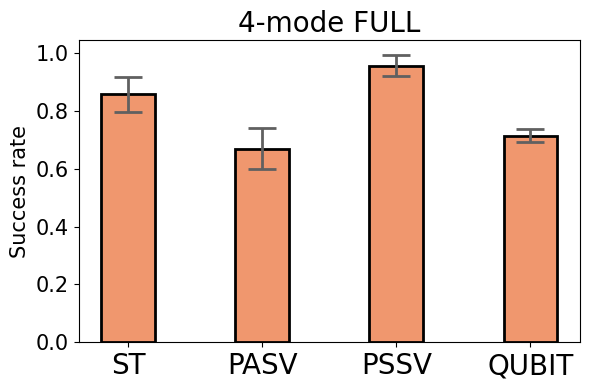

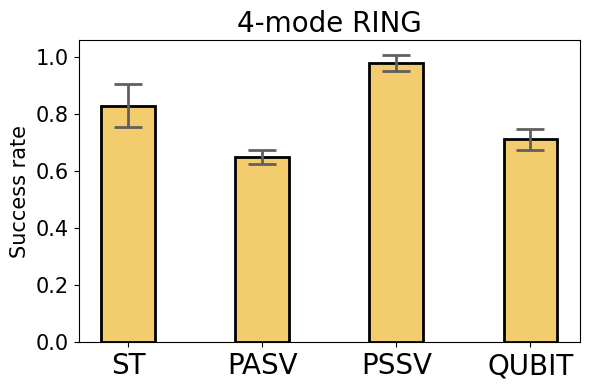

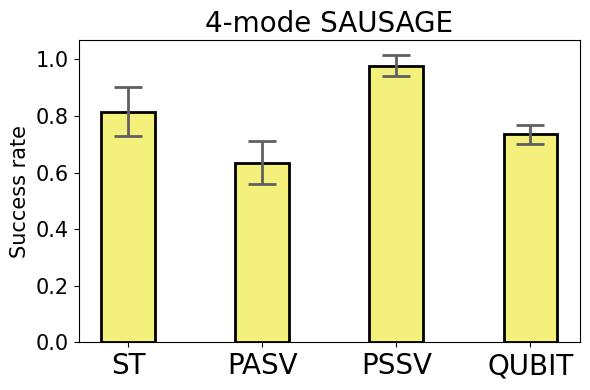

In [13]:
#Plot the probability of correct classification
for i, model in enumerate(models[:3]):
    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(input_types, datas_mean[i], 0.4, yerr=datas_std[i], color=plotcolors[i], ecolor="#606060", error_kw={'elinewidth': 2.0, 'capthick': 2.0}, capsize=10, edgecolor='black', linewidth=2.0)

    #ax.axhline(0.5, c="#f70909", linestyle='--', linewidth=1.5, zorder = 2)
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', labelsize=20)
    ax.set_ylabel('Success rate', fontsize=15)
    plt.title(model, fontsize=20)
    plt.tight_layout()
    plt.show()

# Confusion matrices for each model

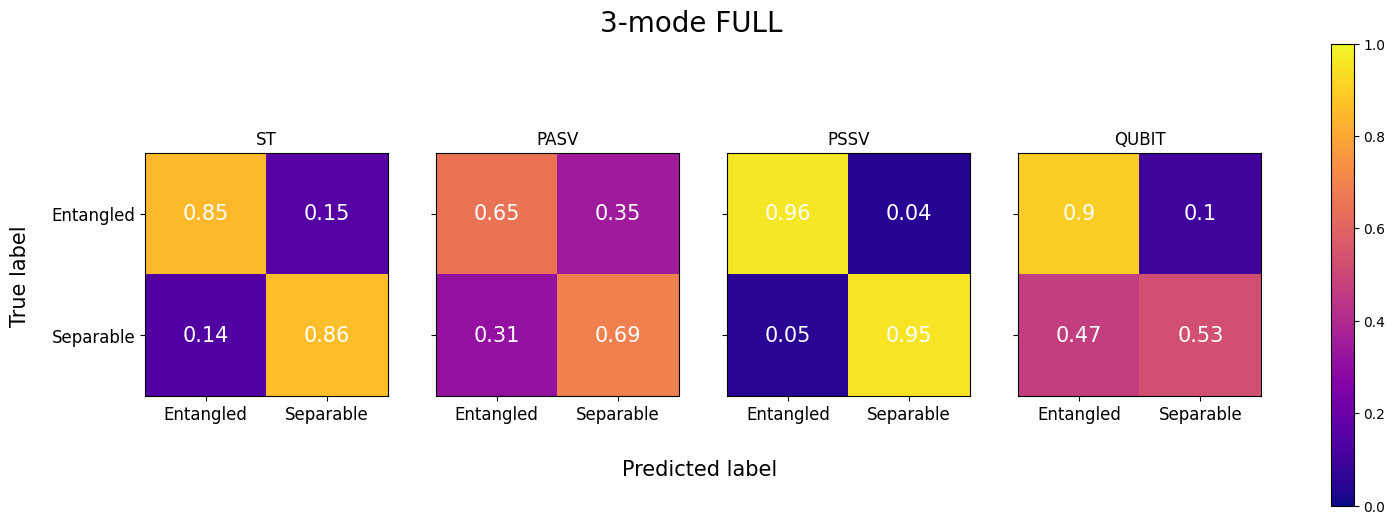

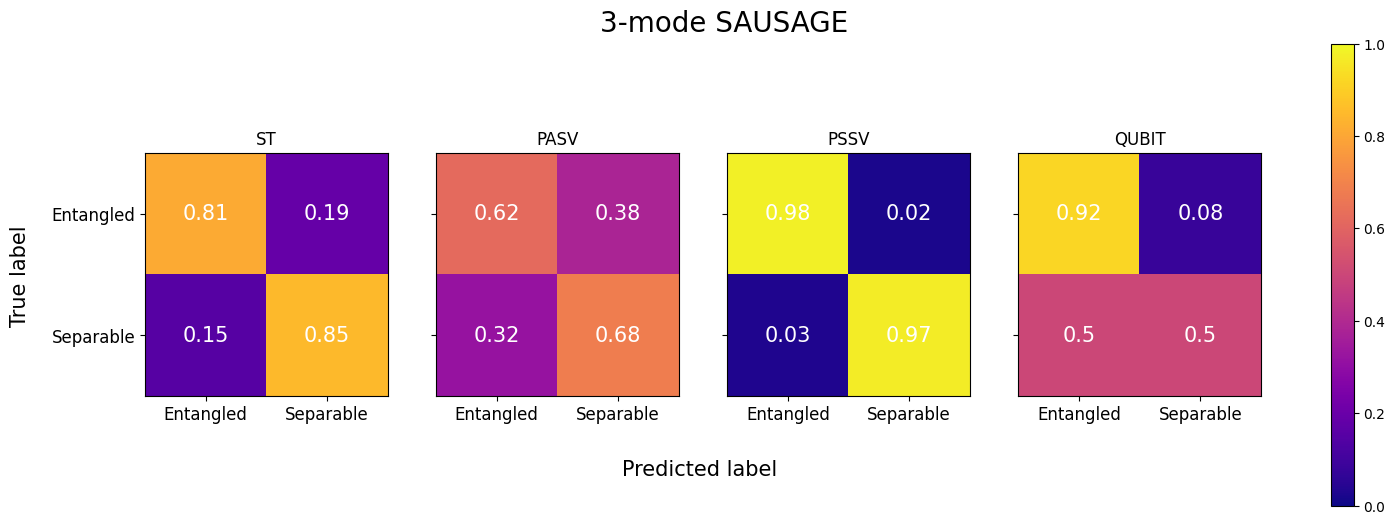

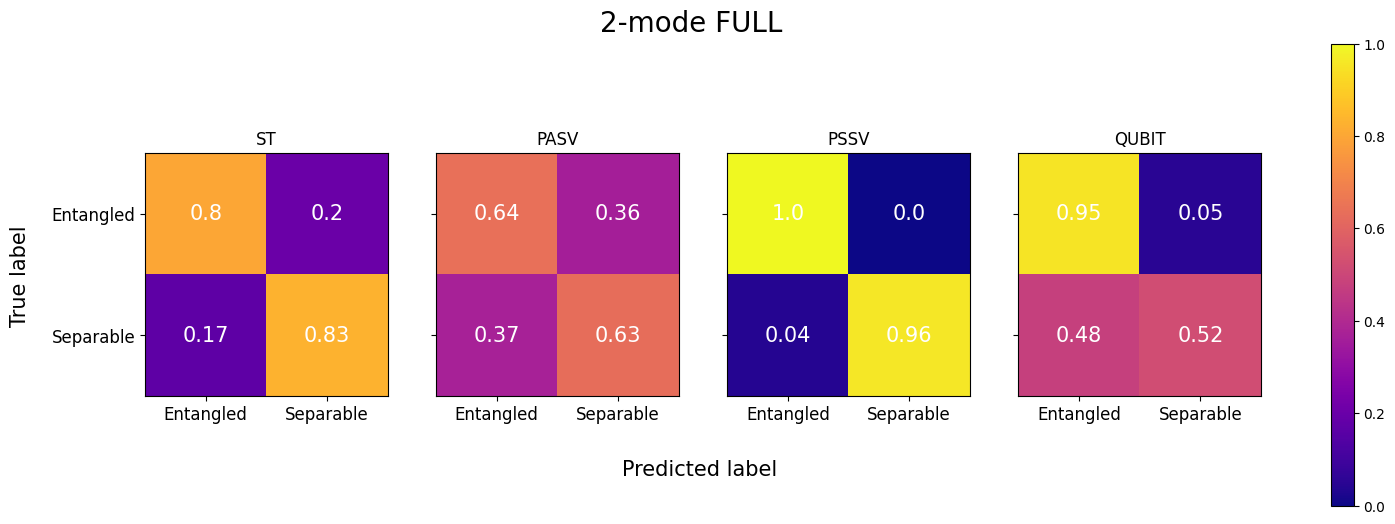

In [8]:
for model, cm_data in zip(models[3:],datas_cm_full_norm):

    fig, axes = plt.subplots(1, len(input_types), figsize=(18, 6))

    for i, cm in enumerate(cm_data):
        cm = np.array([[cm[0], cm[2]],[cm[3], cm[1]]])
        im = axes[i].imshow(cm, cmap='plasma', vmin=0, vmax=1.0)

        for k in range(2):
            for l in range(2):
                axes[i].text(k, l, cm[l, k], ha='center', va='center', fontsize=15, color='white')

        axes[i].set_xticks([0,1],["Entangled", "Separable"],fontsize=12)
        if i == 0:
            axes[i].set_yticks([0,1],["Entangled", "Separable"],fontsize=12)
        else:
            axes[i].set_yticks([0,1],["", ""])
        axes[i].set_title((input_types[i]))

    fig.colorbar(im, ax=axes.ravel().tolist())
    fig.text(0.39, 0.16,'Predicted label',fontsize=15)
    fig.text(0.05, 0.415,'True label',rotation=90,fontsize=15)
    fig.text(0.3775,0.9,model,fontsize=20)
    plt.show()

# A combined histogram for all models

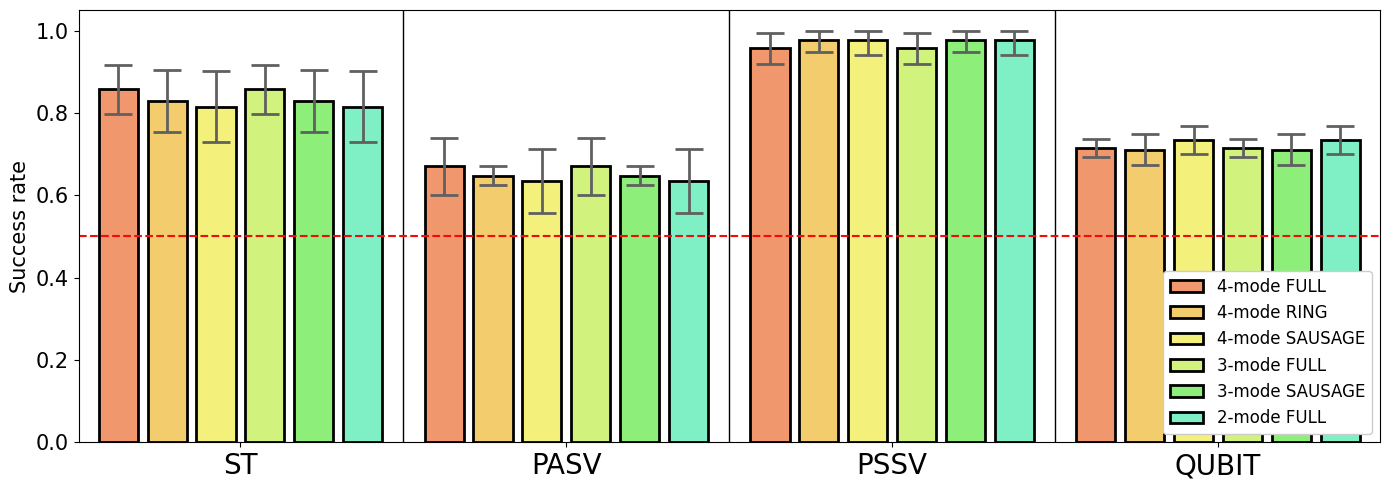

In [9]:
data = np.array(datas_mean + datas_mean)
data_err = np.array(datas_std + datas_std)

fig, ax = plt.subplots(figsize=(14,5))

index = np.arange(len(input_types))
bar_width = 0.12
bar_gap = 0.03  # 👈 controls spacing between bars inside group

ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=20)
ax.set_ylabel('Success rate', fontsize=15)
ax.set_ylim(0,1.05)

for i in range(len(models)):
    ax.bar(index + i * (bar_width + bar_gap), data[i], bar_width, yerr=[data_err[i], data_err[i] - (np.maximum(data[i]+data_err[i],1) - 1)], color=plotcolors[i], ecolor="#606060", error_kw={'elinewidth': 2.0, 'capthick': 2.0}, capsize=10, edgecolor='black', linewidth=2.0, label=models[i])

for group in range(1, len(input_types)):
    ax.axvline(group - 0.125, color='black', linewidth=1, zorder= 0)

ax.axhline(0.5, c="#f70909", linestyle='--', linewidth=1.5, zorder = 2)

# Center x-ticks properly
group_width = len(models) * (bar_width + bar_gap) - bar_gap
plt.xticks(index + group_width / 2 - bar_width / 2, input_types)

plt.margins(x=0.016)
plt.legend(loc='lower right', fontsize=12, framealpha=1.0)
plt.tight_layout()
plt.show()